In [44]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [45]:
file_path = 'reddit_comments_SPY_2018_2022.csv'
df = pd.read_csv(file_path)


In [46]:
df.head()

,Unnamed: 0,Date,id,title,url,comments,most_hapenning_tickers_of_the_day,SPY_close
0,0,2018-01-02,7nm292,"Daily Discussion Thread - January 02, 2018",https://www.reddit.com/r/wallstreetbets/commen...,['SQ- sit and wait it out or DCA down? Origina...,"['WBS', 'MU', 'NFLX', 'MU', 'NFLX', 'DIS', 'ST...",250.769958
1,1,2018-01-03,7nu8sj,"Daily Discussion Thread - January 03, 2018",https://www.reddit.com/r/wallstreetbets/commen...,['mfw I wrote covered calls for WATT yesterday...,"['WATT', 'ALL', 'AMD', 'PM', 'AMD', 'INTC', 'S...",252.356186
2,2,2018-01-04,7o2kg6,"Daily Discussion Thread - January 04, 2018",https://www.reddit.com/r/wallstreetbets/commen...,"['MU', 'Looks like AMD is also affected by the...","['AMD', 'AMD', 'PM']",253.419861
3,3,2018-01-05,7oatdl,"Daily Discussion Thread - January 05, 2018",https://www.reddit.com/r/wallstreetbets/commen...,['What happened to the weekly earnings report ...,"['MU', 'SPY']",255.108719
4,4,2018-01-08,7oy4eb,"Daily Discussion Thread - January 08, 2018",https://www.reddit.com/r/wallstreetbets/commen...,['Who got FDs on NVDA this week? Bought \n\n$2...,"['NVDA', 'MARK', 'TELL', 'TELL', 'SQ', 'UK', '...",255.575119


In [47]:
# Adding wsb/reddit flavor to vader to improve sentiment analysis, score: 4.0 to -4.0
new_words = {
    'citron': -4.0,
    'hidenburg': -4.0,
    'moon': 4.0,
    'highs': 2.0,
    'mooning': 4.0,
    'long': 2.0,
    'short': -2.0,
    'call': 4.0,
    'calls': 4.0,
    'put': -4.0,
    'puts': -4.0,
    'break': 2.0,
    'tendie': 2.0,
     'tendies': 2.0,
     'town': 2.0,
     'overvalued': -3.0,
     'undervalued': 3.0,
     'buy': 4.0,
     'sell': -4.0,
     'gone': -1.0,
     'gtfo': -1.7,
     'paper': -1.7,
     'bullish': 3.7,
     'bearish': -3.7,
     'bagholder': -1.7,
     'stonk': 1.9,
     'green': 1.9,
     'money': 1.2,
     'print': 2.2,
     'rocket': 2.2,
     'bull': 2.9,
     'bear': -2.9,
     'pumping': -1.0,
     'sus': -3.0,
     'offering': -2.3,
     'rip': -4.0,
     'downgrade': -3.0,
     'upgrade': 3.0,
     'maintain': 1.0,
     'pump': 1.9,
     'hot': 1.5,
     'drop': -2.5,
     'rebound': 1.5,
     'crack': 2.5}

In [48]:
df.head()

,Unnamed: 0,Date,id,title,url,comments,most_hapenning_tickers_of_the_day,SPY_close
0,0,2018-01-02,7nm292,"Daily Discussion Thread - January 02, 2018",https://www.reddit.com/r/wallstreetbets/commen...,['SQ- sit and wait it out or DCA down? Origina...,"['WBS', 'MU', 'NFLX', 'MU', 'NFLX', 'DIS', 'ST...",250.769958
1,1,2018-01-03,7nu8sj,"Daily Discussion Thread - January 03, 2018",https://www.reddit.com/r/wallstreetbets/commen...,['mfw I wrote covered calls for WATT yesterday...,"['WATT', 'ALL', 'AMD', 'PM', 'AMD', 'INTC', 'S...",252.356186
2,2,2018-01-04,7o2kg6,"Daily Discussion Thread - January 04, 2018",https://www.reddit.com/r/wallstreetbets/commen...,"['MU', 'Looks like AMD is also affected by the...","['AMD', 'AMD', 'PM']",253.419861
3,3,2018-01-05,7oatdl,"Daily Discussion Thread - January 05, 2018",https://www.reddit.com/r/wallstreetbets/commen...,['What happened to the weekly earnings report ...,"['MU', 'SPY']",255.108719
4,4,2018-01-08,7oy4eb,"Daily Discussion Thread - January 08, 2018",https://www.reddit.com/r/wallstreetbets/commen...,['Who got FDs on NVDA this week? Bought \n\n$2...,"['NVDA', 'MARK', 'TELL', 'TELL', 'SQ', 'UK', '...",255.575119


In [49]:
pip install contractions

Note: you may need to restart the kernel to use updated packages.


In [50]:
import nltk
import string
import contractions
import re

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [51]:
def process_text(text):

    #tokenize the text

    text = word_tokenize(text)

    #Expand contractions
    text = [contractions.fix(word) for word in text]

    #only alphabets
    text = [ re.sub('[^A-Za-z]+', '', word) for word in text]

    #lowercase
    text = [word.lower() for word in text if word.isalpha()]

    #stopwords
    stop_words = set(stopwords.words('english'))
    text = [word for word in text if word not in stop_words]

    #Lemmatizer
    text = [WordNetLemmatizer().lemmatize(word) for word in text]

    text = ' '.join(text)

    return text


In [52]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\11096\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\11096\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\11096\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [53]:

df['processed_comments'] = df['comments'].apply(process_text)

In [54]:
df.head()

,Unnamed: 0,Date,id,title,url,comments,most_hapenning_tickers_of_the_day,SPY_close,processed_comments
0,0,2018-01-02,7nm292,"Daily Discussion Thread - January 02, 2018",https://www.reddit.com/r/wallstreetbets/commen...,['SQ- sit and wait it out or DCA down? Origina...,"['WBS', 'MU', 'NFLX', 'MU', 'NFLX', 'DIS', 'ST...",250.769958,sq sit wait dca original buy mjx bois atn new ...
1,1,2018-01-03,7nu8sj,"Daily Discussion Thread - January 03, 2018",https://www.reddit.com/r/wallstreetbets/commen...,['mfw I wrote covered calls for WATT yesterday...,"['WATT', 'ALL', 'AMD', 'PM', 'AMD', 'INTC', 'S...",252.356186,mfw wrote covered call watt yesterday thinking...
2,2,2018-01-04,7o2kg6,"Daily Discussion Thread - January 04, 2018",https://www.reddit.com/r/wallstreetbets/commen...,"['MU', 'Looks like AMD is also affected by the...","['AMD', 'AMD', 'PM']",253.419861,mu look like amd also affected similar big int...
3,3,2018-01-05,7oatdl,"Daily Discussion Thread - January 05, 2018",https://www.reddit.com/r/wallstreetbets/commen...,['What happened to the weekly earnings report ...,"['MU', 'SPY']",255.108719,happened weekly earnings report post stickied ...
4,4,2018-01-08,7oy4eb,"Daily Discussion Thread - January 08, 2018",https://www.reddit.com/r/wallstreetbets/commen...,['Who got FDs on NVDA this week? Bought \n\n$2...,"['NVDA', 'MARK', 'TELL', 'TELL', 'SQ', 'UK', '...",255.575119,got fds nvda week bought nn strike near close ...


In [55]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('vader_lexicon')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\11096\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\11096\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\11096\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\11096\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\11096\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\11096\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [56]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()
sia.lexicon.update(new_words)

def vader_sentiment_score(text):
    return sia.polarity_scores(text)['compound']

In [57]:
df_small = df.head(50000).copy()

df_small['sentiment_score'] = df_small['processed_comments'].astype(str).apply(
    lambda x: sia.polarity_scores(x)['compound']
)

In [58]:
df['sentiment_score'] = df['processed_comments'].apply(vader_sentiment_score)


In [59]:
df.head()


,Unnamed: 0,Date,id,title,url,comments,most_hapenning_tickers_of_the_day,SPY_close,processed_comments,sentiment_score
0,0,2018-01-02,7nm292,"Daily Discussion Thread - January 02, 2018",https://www.reddit.com/r/wallstreetbets/commen...,['SQ- sit and wait it out or DCA down? Origina...,"['WBS', 'MU', 'NFLX', 'MU', 'NFLX', 'DIS', 'ST...",250.769958,sq sit wait dca original buy mjx bois atn new ...,0.9956
1,1,2018-01-03,7nu8sj,"Daily Discussion Thread - January 03, 2018",https://www.reddit.com/r/wallstreetbets/commen...,['mfw I wrote covered calls for WATT yesterday...,"['WATT', 'ALL', 'AMD', 'PM', 'AMD', 'INTC', 'S...",252.356186,mfw wrote covered call watt yesterday thinking...,0.8218
2,2,2018-01-04,7o2kg6,"Daily Discussion Thread - January 04, 2018",https://www.reddit.com/r/wallstreetbets/commen...,"['MU', 'Looks like AMD is also affected by the...","['AMD', 'AMD', 'PM']",253.419861,mu look like amd also affected similar big int...,-0.6249
3,3,2018-01-05,7oatdl,"Daily Discussion Thread - January 05, 2018",https://www.reddit.com/r/wallstreetbets/commen...,['What happened to the weekly earnings report ...,"['MU', 'SPY']",255.108719,happened weekly earnings report post stickied ...,0.8803
4,4,2018-01-08,7oy4eb,"Daily Discussion Thread - January 08, 2018",https://www.reddit.com/r/wallstreetbets/commen...,['Who got FDs on NVDA this week? Bought \n\n$2...,"['NVDA', 'MARK', 'TELL', 'TELL', 'SQ', 'UK', '...",255.575119,got fds nvda week bought nn strike near close ...,0.9938


In [69]:
print(df.shape)

(985, 11)


In [60]:
import numpy as np

df['return'] = np.log(df['SPY_close'] / df['SPY_close'].shift(1))
df = df.dropna()

In [68]:
df.head()

,Unnamed: 0,Date,id,title,url,comments,most_hapenning_tickers_of_the_day,SPY_close,processed_comments,sentiment_score,return
1,1,2018-01-03,7nu8sj,"Daily Discussion Thread - January 03, 2018",https://www.reddit.com/r/wallstreetbets/commen...,['mfw I wrote covered calls for WATT yesterday...,"['WATT', 'ALL', 'AMD', 'PM', 'AMD', 'INTC', 'S...",252.356186,mfw wrote covered call watt yesterday thinking...,0.8218,0.006306
2,2,2018-01-04,7o2kg6,"Daily Discussion Thread - January 04, 2018",https://www.reddit.com/r/wallstreetbets/commen...,"['MU', 'Looks like AMD is also affected by the...","['AMD', 'AMD', 'PM']",253.419861,mu look like amd also affected similar big int...,-0.6249,0.004206
3,3,2018-01-05,7oatdl,"Daily Discussion Thread - January 05, 2018",https://www.reddit.com/r/wallstreetbets/commen...,['What happened to the weekly earnings report ...,"['MU', 'SPY']",255.108719,happened weekly earnings report post stickied ...,0.8803,0.006642
4,4,2018-01-08,7oy4eb,"Daily Discussion Thread - January 08, 2018",https://www.reddit.com/r/wallstreetbets/commen...,['Who got FDs on NVDA this week? Bought \n\n$2...,"['NVDA', 'MARK', 'TELL', 'TELL', 'SQ', 'UK', '...",255.575119,got fds nvda week bought nn strike near close ...,0.9938,0.001827
5,5,2018-01-09,7p6oki,"Daily Discussion Thread - January 09, 2018",https://www.reddit.com/r/wallstreetbets/commen...,"[""I'm selling half my position in amd regardle...","['AMD', 'BABA', 'NVDA', 'MU', 'SQ', 'AMD', 'SQ...",256.153625,selling half position amd regardless price pre...,0.5574,0.002261


In [61]:
X = df['sentiment_score']
y = df['return']


In [62]:
import statsmodels.api as sm
model = sm.OLS(y, X).fit()
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 return   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):              0.011
Method:                 Least Squares   F-statistic:                              12.16
Date:                Sat, 13 Dec 2025   Prob (F-statistic):                    0.000511
Time:                        23:45:18   Log-Likelihood:                          2855.9
No. Observations:                 985   AIC:                                     -5710.
Df Residuals:                     984   BIC:                                     -5705.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------

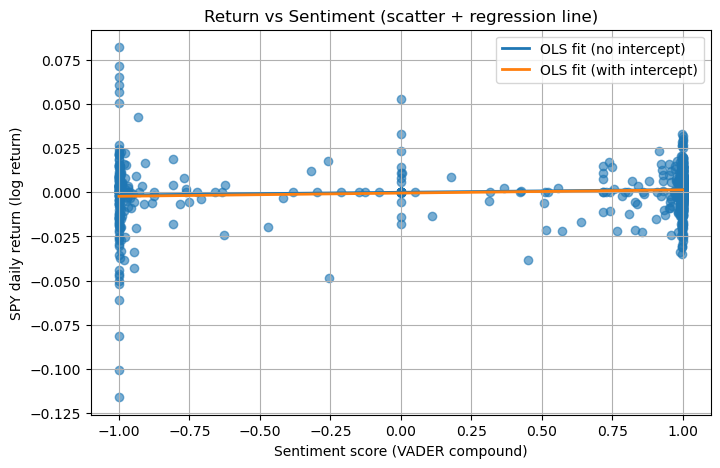

In [63]:
# 取出数据（去掉缺失）
d = df[['sentiment_score', 'return']].dropna().copy()
x = d['sentiment_score'].astype(float).values
y = d['return'].astype(float).values

# 无截距 OLS 斜率：beta = sum(x*y)/sum(x^2)
beta_no_const = (x @ y) / (x @ x)

# 带截距 OLS：用 polyfit 得到 (slope, intercept)
beta_const, alpha_const = np.polyfit(x, y, 1)

xx = np.linspace(x.min(), x.max(), 200)
yy_no_const = beta_no_const * xx
yy_const = alpha_const + beta_const * xx

plt.figure(figsize=(8,5))
plt.scatter(x, y, alpha=0.6)
plt.plot(xx, yy_no_const, linewidth=2, label='OLS fit (no intercept)')
plt.plot(xx, yy_const, linewidth=2, label='OLS fit (with intercept)')
plt.xlabel('Sentiment score (VADER compound)')
plt.ylabel('SPY daily return (log return)')
plt.title('Return vs Sentiment (scatter + regression line)')
plt.grid(True)
plt.legend()
plt.show()

In [64]:
from sklearn.linear_model import LinearRegression
import numpy as np

# 取需要的列，去掉缺失
d = df[['sentiment_score', 'return']].dropna()

X = d[['sentiment_score']].values   # 一定要是 2D
y = d['return'].values

In [65]:
lr = LinearRegression()
lr.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [66]:
print("Intercept (alpha):", lr.intercept_)
print("Coefficient (beta):", lr.coef_[0])
print("R-squared:", lr.score(X, y))

Intercept (alpha): -0.00045353274144219213
Coefficient (beta): 0.0018167958553314727
R-squared: 0.011477225841571848


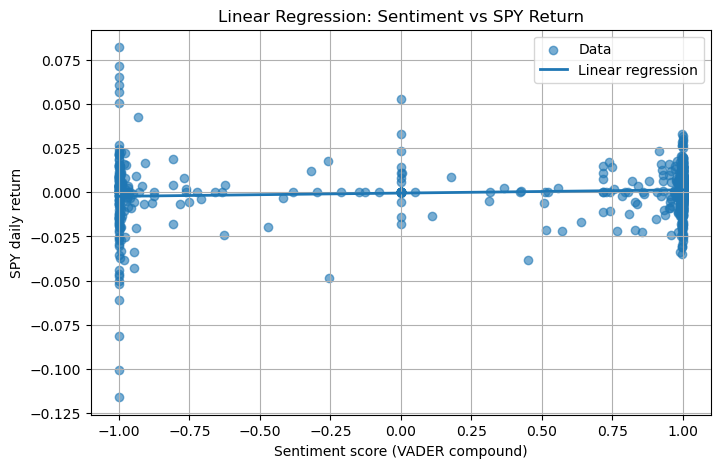

In [67]:
import matplotlib.pyplot as plt

# 生成拟合线
x_line = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
y_line = lr.predict(x_line)

plt.figure(figsize=(8,5))
plt.scatter(X, y, alpha=0.6, label='Data')
plt.plot(x_line, y_line, linewidth=2, label='Linear regression')
plt.xlabel('Sentiment score (VADER compound)')
plt.ylabel('SPY daily return')
plt.title('Linear Regression: Sentiment vs SPY Return')
plt.legend()
plt.grid(True)
plt.show()